# US-006：事件提取与 Epoching

**目标：** 从连续数据中提取事件、切分 Epochs，为 ERP 分析做准备。

**核心：** Events 数组 → Epochs 对象 → 条件间对比

## 1. 准备数据（带预处理的 sample 数据）

In [19]:
import mne
import numpy as np
import os

# 目录配置
data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
# 每次运行强制更新 config
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)
print("=" * 80)
print("config file =", mne.get_config_path())
print("=" * 80)
# 打印config 内容,友好格式
config = mne.get_config()
for key, value in config.items():
    print(f"* {key:25s}: {value}")

# 加载 sample 数据
sample_dir = mne.datasets.sample.data_path()
raw_fname = sample_dir / "MEG" / "sample" / "sample_audvis_raw.fif"
raw: mne.io.RawArray =  mne.io.read_raw_fif(raw_fname, preload=True)

# 只保留 EEG + STIM 通道
raw.pick_types(eeg=True, stim=True)
print(f"通道: {raw.ch_names}")
# 打印通道数
print(f"通道数: {raw.info['nchan']}")


config file = /Users/usst_ziyi/.mne/mne-python.json
* MNE_BROWSE_RAW_SIZE      : 20.416666666666668,12.819444444444445
* MNE_DATA                 : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_DATASETS_SAMPLE_PATH : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_PATH                 : ./datasets
Opening raw data file /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
通道: ['STI 001', 'STI 002', 'STI 003', 'STI 004', 'STI 005', 'STI 006', 'STI 014', 'STI 015', 'STI 016', 'EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 00

## 2. 从 Stim 通道提取 Events

Stim 通道记录了刺激呈现的时刻，`find_events()` 自动检测电平变化。

In [20]:
# 从 STIM 通道提取事件
events = mne.find_events(raw, stim_channel='STI 014')
print(f"事件总数: {len(events)}")
print(f"事件 ID: {np.unique(events[:, 2])}")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
事件总数: 320
事件 ID: [ 1  2  3  4  5 32]


### 2.1 find_events 参数详解

| 参数 | 含义 | 常用值 |
|------|------|--------|
| `stim_channel` | Stim 通道名 | 'STI 014' 或 'auto' |
| `output` | 事件时间表示 | 'onset'（上升沿）、'offset'、'step' |
| `consecutive` | 是否允许连续相同值 | True（默认） |
| `min_duration` | 事件最短持续（采样点） | 0 |
| `shortest_event` | 最短事件 | 2 |
| `mask` | 事件 ID 掩码 | 0 表示不过滤 |
| `mask_type` | 掩码逻辑 | 'and' / 'not_and' |

## 3. 事件 ID 映射

把事件 ID 数字映射为有意义的条件名。

In [21]:
# sample 数据：听觉左耳=1, 听觉右耳=2, 视觉左=3, 视觉右=4, 笑脸=5, 按键=32
event_id = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
    'smiley': 5,
}

# 也可以只挑关心的条件
event_id_subset = {
    'auditory': 1,   # 只取左耳听觉（合并左右）
    'visual': 3,     # 只取左视野视觉
}
print(f"事件映射: {event_id}")

事件映射: {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'smiley': 5}


## 4. 创建 Epochs

关键参数：`tmin/tmax`（时间窗口）、`baseline`（基线）、`reject`（拒绝准则）。

In [23]:
# 参数
tmin, tmax = -0.2, 0.8    # -200ms 到 800ms
baseline = (-0.2, 0)       # 用事件前的数据做基线

# 创建 Epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    preload=True,
    reject=dict(eeg=150e-6),   # 峰峰值 > 150 µV 的 epoch 丢弃
    flat=dict(eeg=1e-6),       # 峰峰值 < 1 µV 的 epoch 丢弃（死道）
    verbose=False,
)
print(epochs)

<Epochs | 238 events (all good), -0.2 – 0.799 s (baseline -0.2 – 0 s), ~77.2 MiB, data loaded,
 'auditory/left': 51
 'auditory/right': 60
 'visual/left': 63
 'visual/right': 53
 'smiley': 11>


### 4.1 拒绝准则详解

- **`reject`**：峰峰值阈值，超过的 epoch 扔掉
- **`flat`**：最低活动阈值，低于的认为是死道
- 单位是 V（150e-6 = 150 µV）
- 可以分别对不同通道类型设阈值：`dict(eeg=150e-6, eog=250e-6)`

In [5]:
# 查看被拒绝的 epochs
print(f"被拒绝的 epochs: {epochs.drop_log[:10]}")  # 前 10 个
print(f"\n通过率: {len(epochs)}/{len(events)}")
# 统计非空drop_log
print(f"非空drop_log 数量: {sum([1 for log in epochs.drop_log if log])}")


被拒绝的 epochs: (('EEG 001', 'EEG 002', 'EEG 003', 'EEG 007'), (), (), (), (), (), (), (), (), ())

通过率: 238/320
非空drop_log 数量: 82


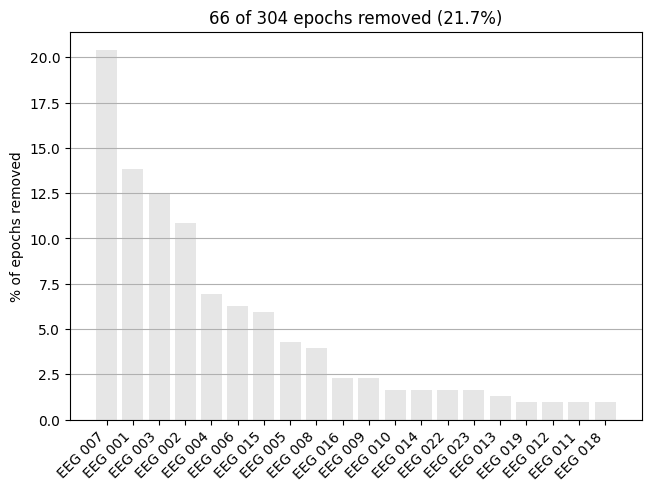

In [6]:
# 查看被剔除的原因统计图
fig = epochs.plot_drop_log()

# 或者直接看保留下来的数据波形，确认没有明显的伪迹
# epochs.plot(n_epochs=10) 

### 4.2 平衡条件间的 Trial 数

不同条件可能 trials 数不同，做统计检验前需要平衡。

In [7]:
# 平衡：以最少 trial 数为准，随机下采样
epochs.equalize_event_counts(event_ids=['auditory/left', 'visual/left'], method='mintime')
print(f"平衡后:")
for cond in ['auditory/left', 'visual/left']:
    n = len(epochs[cond])
    print(f"  {cond}: {n} trials")

Dropped 12 epochs: 34, 81, 92, 129, 146, 150, 152, 153, 156, 190, 195, 203
平衡后:
  auditory/left: 51 trials
  visual/left: 51 trials


## 5. 按条件索引 Epochs

用 event_id 字典的 key 快速提取某个条件的全部 trials。

In [8]:
# 提取听觉和视觉的 Epochs
epochs_aud = epochs['auditory']
epochs_vis = epochs['visual']

print(f"听觉: {len(epochs_aud)} trials")
print(f"视觉: {len(epochs_vis)} trials")

# 多条件混合索引
epochs_all = epochs[['auditory', 'visual']]
print(f"听觉+视觉: {len(epochs_all)} trials")

听觉: 111 trials
视觉: 104 trials
听觉+视觉: 215 trials


## 6. 对比不同条件的波形

快速可视化不同条件下的平均 ERP。

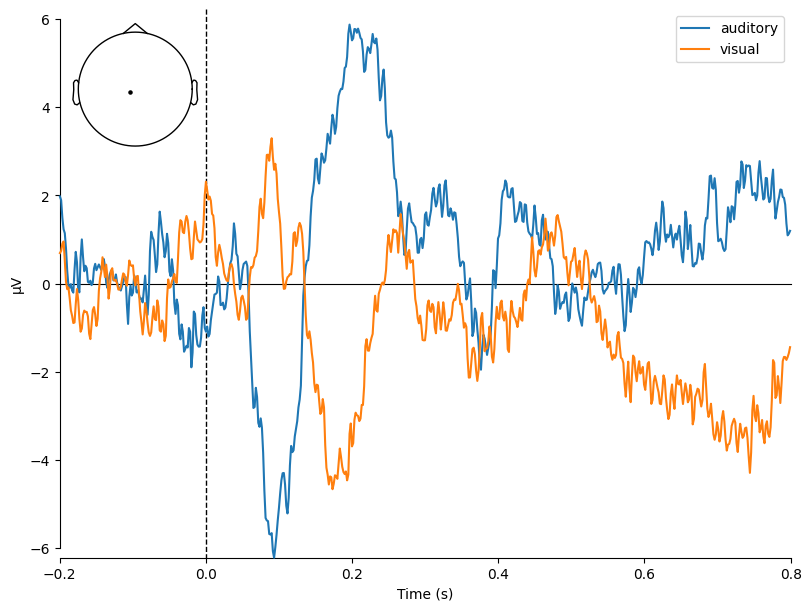

[<Figure size 800x600 with 2 Axes>]

In [9]:
# 选择 Cz 通道（中央顶叶，ERP 常看的通道）
picks = ['EEG 030']  # 近似 Cz

# 对比听觉 vs 视觉
evoked_aud = epochs['auditory'].average().pick(picks)
evoked_vis = epochs['visual'].average().pick(picks)

# 绘制对比图
mne.viz.plot_compare_evokeds(
    evokeds=dict(auditory=evoked_aud, visual=evoked_vis),
    legend='upper right',
    show_sensors='upper left',
)

## 7. Epochs 的常用操作

| 操作 | 方法 |
|------|------|
| 取数据 | `epochs.get_data()` → `(n_epochs, n_channels, n_times)` |
| 按条件索引 | `epochs['condition_name']` |
| 平均 | `epochs.average()` 或 `epochs['cond'].average()` |
| 滤波 | `epochs.filter(l_freq=1, h_freq=40)` |
| 保存 | `epochs.save('epochs.fif')` |
| 裁剪 | `epochs.crop(tmin=-0.1, tmax=0.5)` |
| 降采样 | `epochs.resample(150)` |
| 标准误差 | `epochs.standard_error()` |

## 8. 练习

1. 尝试不同的 `reject` 阈值，看看丢弃了多少 trials
2. 对比 `baseline=(None, 0)` vs `baseline=(-0.2, -0.05)` 对 ERP 的影响
3. 用 `epochs.plot_image()` 查看单试次热力图

Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


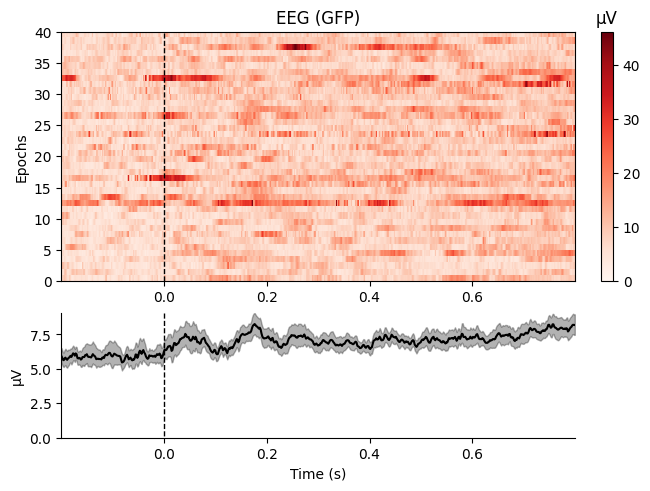

Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


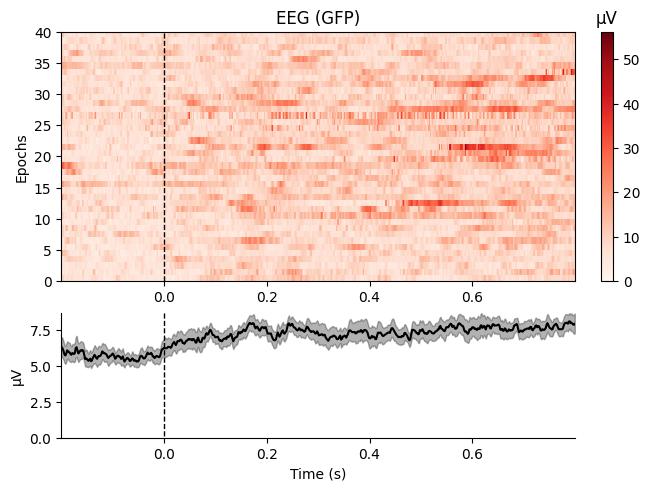

[<Figure size 640x480 with 3 Axes>]

In [18]:
epochs['visual']['left'][:40].plot_image()
epochs['visual']['right'][:40].plot_image()


Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


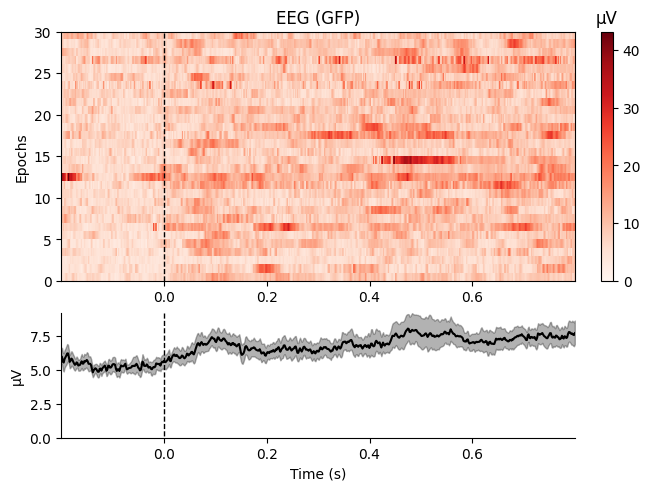

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


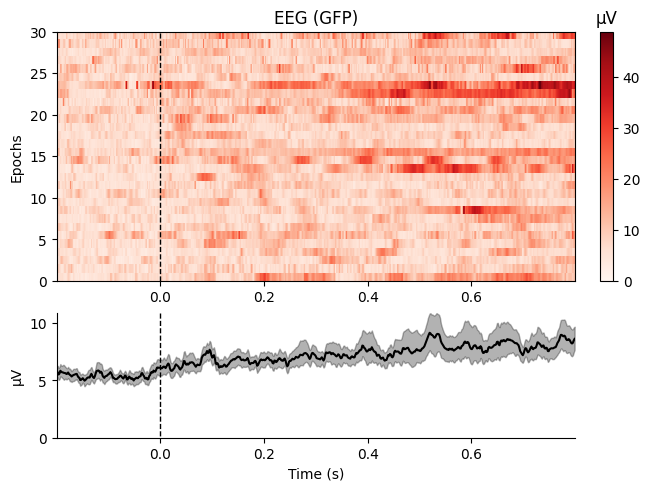

[<Figure size 640x480 with 3 Axes>]

In [11]:
epochs['auditory']['left'][:30].plot_image()
epochs['auditory']['right'][:30].plot_image()
